In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
file_path = '../.data/A42_1000000383/A42_1000000383.csv'
df = pd.read_csv(file_path)

print("Dataset Info:")
df.info()

display(df.head())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mon_feature_id           1 non-null      int64  
 1   date_time                1 non-null      str    
 2   sample_begin_depth       1 non-null      str    
 3   institution_abbr         1 non-null      str    
 4   preservative_abbr        1 non-null      str    
 5   Ca_Diss_Water            1 non-null      float64
 6   Ca_Diss_Water_dl         1 non-null      int64  
 7   Cl_Diss_Water            1 non-null      float64
 8   Cl_Diss_Water_dl         1 non-null      int64  
 9   DMS_Tot_Water            1 non-null      float64
 10  DMS_Tot_Water_dl         1 non-null      str    
 11  EC_Phys_Water            1 non-null      int64  
 12  EC_Phys_Water_dl         1 non-null      int64  
 13  F_Diss_Water             1 non-null      float64
 14  F_Diss_Water_dl          1 

,mon_feature_id,date_time,sample_begin_depth,institution_abbr,preservative_abbr,Ca_Diss_Water,Ca_Diss_Water_dl,Cl_Diss_Water,Cl_Diss_Water_dl,DMS_Tot_Water,...,PO4_P_Diss_Water,PO4_P_Diss_Water_dl,Si_Diss_Water,Si_Diss_Water_dl,SO4_Diss_Water,SO4_Diss_Water_dl,TAL_Diss_Water,TAL_Diss_Water_dl,Station,Qat
0,1000000383,2002-01-29 12:17:00,#n/a,DWS-RQIS,HGCL2,24.145,1,24.984,10,412.175,...,0.006,0.011,10.997,0.4,12.361,4,211.654,4,2428AC00453,A42E


In [4]:
df.replace('#n/a', np.nan, inplace=True)

dissolved_vars = [col for col in df.columns if col.endswith('_Diss_Water')]
dl_vars = [col for col in df.columns if col.endswith('_dl')]
chem_df = df[dissolved_vars].copy()

for col in chem_df.columns:
    chem_df[col] = pd.to_numeric(chem_df[col], errors='coerce')

sample_data = chem_df.iloc[0].sort_values(ascending=False)
sample_data = pd.DataFrame({'Concentration (mg/L)': sample_data})

print("Sorted Chemical Concentrations:")
display(sample_data)

Sorted Chemical Concentrations:


,Concentration (mg/L)
TAL_Diss_Water,211.654
Na_Diss_Water,69.813
Cl_Diss_Water,24.984
Ca_Diss_Water,24.145
Mg_Diss_Water,15.654
SO4_Diss_Water,12.361
Si_Diss_Water,10.997
pH_Diss_Water,8.443
K_Diss_Water,1.344
NO3_NO2_N_Diss_Water,1.192


/tmp/ipykernel_56333/1922660551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


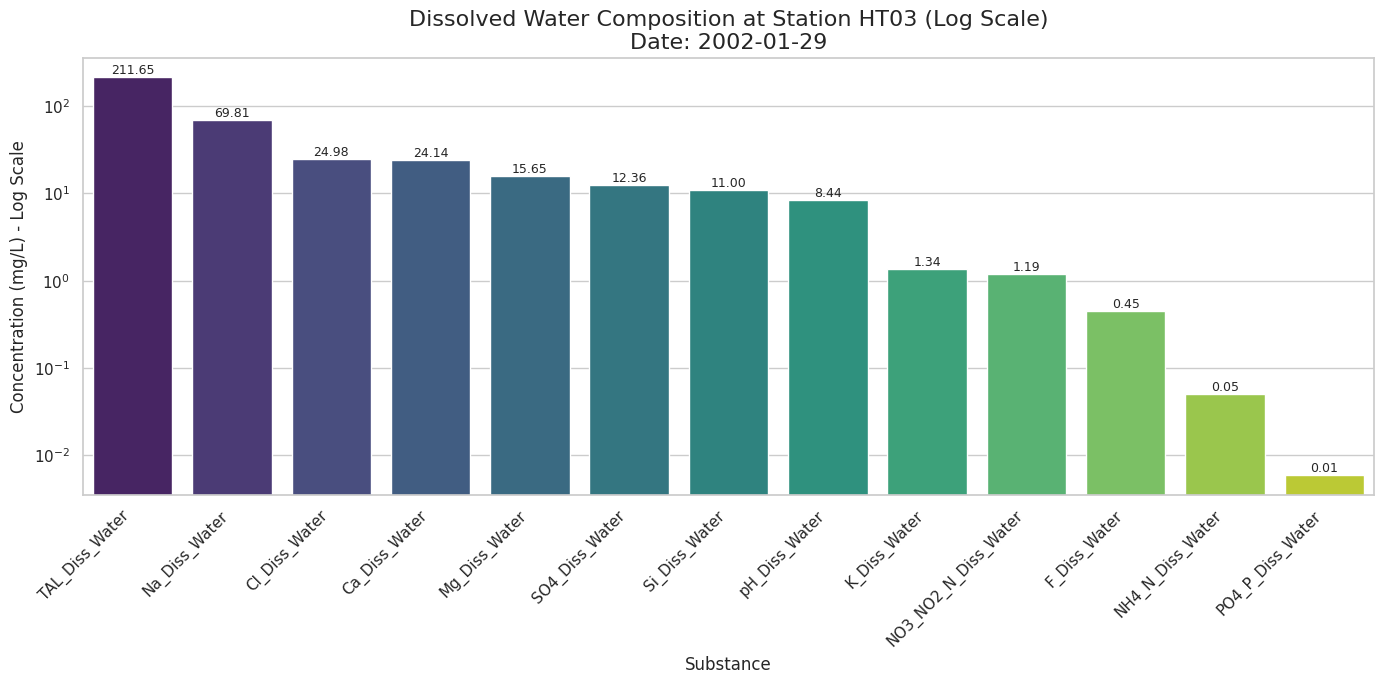

In [5]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=sample_data.index, 
    y='Concentration (mg/L)', 
    data=sample_data, 
    palette="viridis"
)

ax.set_yscale("log")

plt.title('Dissolved Water Composition at Station HT03 (Log Scale)\nDate: 2002-01-29', fontsize=16)
plt.xlabel('Substance', fontsize=12)
plt.ylabel('Concentration (mg/L) - Log Scale', fontsize=12)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(sample_data['Concentration (mg/L)']):
    ax.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

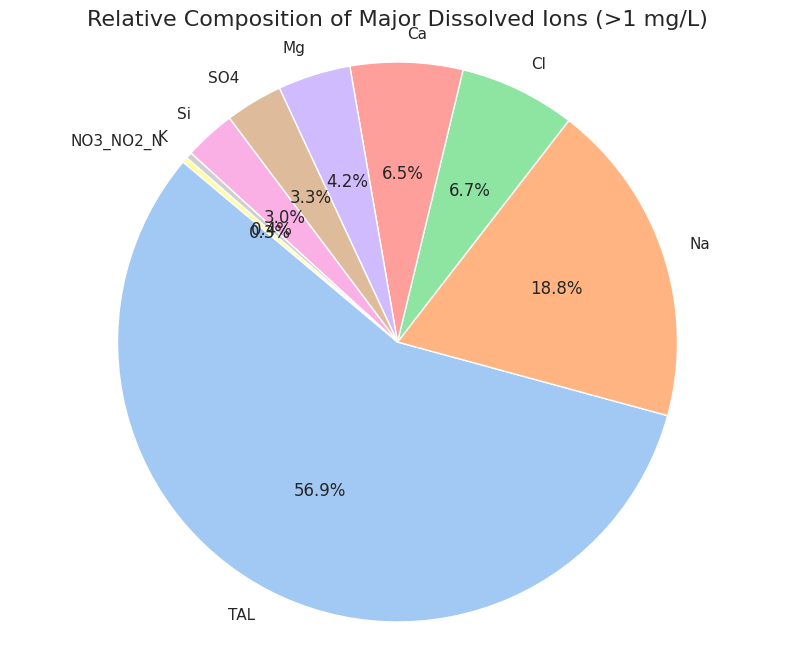

In [6]:
major_ions = sample_data[
    (~sample_data.index.isin(['pH_Diss_Water'])) & 
    (sample_data['Concentration (mg/L)'] > 1.0)
]

plt.figure(figsize=(10, 8))
plt.pie(
    major_ions['Concentration (mg/L)'], 
    labels=[label.replace('_Diss_Water', '') for label in major_ions.index], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=sns.color_palette("pastel")
)

plt.title('Relative Composition of Major Dissolved Ions (>1 mg/L)', fontsize=16)
plt.axis('equal') 
plt.show()

In [8]:
comparison_df = pd.DataFrame()

for col in dissolved_vars:
    base_name = col.replace('_Diss_Water', '')
    dl_col = col + '_dl'
    
    if dl_col in df.columns:
        val = df[col].iloc[0]
        dl_val = df[dl_col].iloc[0]
        
        comparison_df = pd.concat([comparison_df, pd.DataFrame({
            'Substance': [base_name],
            'Value': [val],
            'Detection_Limit': [dl_val]
        })], ignore_index=True)

comparison_df['Value'] = pd.to_numeric(comparison_df['Value'], errors='coerce')
comparison_df['Detection_Limit'] = pd.to_numeric(comparison_df['Detection_Limit'], errors='coerce')

comparison_df['Near_DL'] = comparison_df['Value'] <= (comparison_df['Detection_Limit'] * 0.5)

display(comparison_df)

,Substance,Value,Detection_Limit,Near_DL
0,Ca,24.145,1.000,False
1,Cl,24.984,10.000,False
2,F,0.453,0.100,False
3,K,1.344,0.300,False
4,Mg,15.654,1.000,False
5,Na,69.813,2.000,False
6,NH4_N,0.051,0.040,False
7,NO3_NO2_N,1.192,0.040,False
8,pH,8.443,2.000,False
9,PO4_P,0.006,0.011,False
